## 1. Import necessary packages

In [ ]:
images = [
    '000000000785.jpg', '000000005477.jpg', '000000007278.jpg', '000000007278.jpg',
    '000000007977.jpg', '000000015440.jpg', '000000016502.jpg', '000000118594.jpg',
    '000000119911.jpg'
]

In [31]:
import cv2
import torch

from matplotlib import pyplot as plt
from util.utils import load_state_dict, load_checkpoint
from util.visualize import plot_bounding_boxes_on_image

## 2. Load a model and class information

We encode class information into the checkpoint, use our defined `load_state_dict` to handle it.

In [76]:
import importlib
import models.detectors.dino
importlib.reload(models.detectors.dino)

<module 'models.detectors.dino' from '/root/Relation-DETR/models/detectors/dino.py'>

In [77]:
from configs.relation_detr.relation_detr_resnet50_800_1333 import model
weight = load_checkpoint("https://github.com/xiuqhou/Relation-DETR/releases/download/v1.0.0/relation_detr_resnet50_800_1333_coco_1x.pth")
load_state_dict(model, weight)
model = model.eval()

Downloading: "https://github.com/xiuqhou/Relation-DETR/releases/download/v1.0.0/relation_detr_resnet50_800_1333_coco_1x.pth" to /root/.cache/torch/hub/checkpoints/relation_detr_resnet50_800_1333_coco_1x.pth


KeyboardInterrupt: 

In [85]:
from configs.dino_pp.dino_pp_resnet50_800_1333 import model
weight = load_checkpoint("/root/autodl-tmp/dino/dino-v3.1-cur-24ep_dino_pp_resnet50_800_1333/train/decoder-query-optm-v3.3.1-stable-group-div-sparse-loss_2025-01-21-15_36_02/best_ap.pth")
load_state_dict(model, weight)
model = model.eval()

In [55]:
print(type(model))

<class 'models.detectors.dino.DINO'>


In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [104]:
import os
import cv2
import json
import random
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.transforms as T
from torchvision.transforms import functional as F

def visualize_weights_tsne(weights, labels, title="t-SNE Visualization of Group Weights"):
    # 定义类别分组
    category_groups = {
        'animals': [
            'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
            'mouse', 'rabbit', 'hamster', 'squirrel', 'deer', 'fox', 'panda', 'butterfly', 'fish'
        ],
        'vehicles': [
            'car', 'bicycle', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
            'traffic light', 'fire hydrant', 'stop sign', 'parking meter'
        ],
        'person': ['person'],
        'other': []  # 捕获其他所有类别
    }
    
    # 创建类别到组的映射
    category_to_group = {}
    for group_name, categories in category_groups.items():
        for category in categories:
            category_to_group[category] = group_name
    
    # 将标签转换为组标签，未知类别归为'other'
    group_labels = []
    for label in labels:
        if label in category_to_group:
            group_labels.append(category_to_group[label])
        else:
            print(f"Unknown category: {label}, assigning to 'other'")
            group_labels.append('other')
    
    # 执行t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    weights_2d = tsne.fit_transform(weights)
    
    # 设置绘图
    plt.figure(figsize=(12, 8))
    
    # 为每个组设置颜色
    group_colors = {
        'animals': 'blue',
        'vehicles': 'red',
        'person': 'green',
        'other': 'gray'
    }
    
    # 绘制散点图
    for group in group_colors:
        mask = np.array(group_labels) == group
        if np.any(mask):  # 只有当有该组的数据时才绘制
            plt.scatter(
                weights_2d[mask, 0],
                weights_2d[mask, 1],
                c=group_colors[group],
                label=f"{group} (n={np.sum(mask)})",
                alpha=0.6
            )
    
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # 打印每个组的数量和具体类别
    print("\nDetailed category distribution:")
    category_counts = Counter(labels)
    for cat, count in category_counts.most_common():
        group = category_to_group.get(cat, 'other')
        print(f"{cat} ({group}): {count} images")
    
    plt.show()


In [148]:
def save_tsne_with_thumbnails(weights, labels, image_paths, output_path='tsne_with_images.png'):
    print("Starting t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    weights_2d = tsne.fit_transform(weights)
    
    print("Creating figure...")
    # 增加图片大小
    plt.figure(figsize=(30, 30), facecolor='white')
    
    # 计算坐标范围
    x_min, x_max = weights_2d[:, 0].min(), weights_2d[:, 0].max()
    y_min, y_max = weights_2d[:, 1].min(), weights_2d[:, 1].max()
    
    # 设置坐标轴范围，增加间距
    margin = (x_max - x_min) * 0.1  # 10% 边距
    plt.xlim(x_min - margin, x_max + margin)
    plt.ylim(y_min - margin, y_max + margin)
    
    print("Processing images...")
    for idx, (coord, label) in enumerate(zip(weights_2d, labels)):
        try:
#             # 使用cv2加载图片，增加缩略图大小
#             img = cv2.imread(image_paths[idx])
#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = cv2.resize(img, (64, 64))  # 增加缩略图尺寸
            
#             # 创建缩略图，调整zoom
#             imagebox = OffsetImage(img, zoom=1.0)  # 增加zoom值
#             ab = AnnotationBbox(imagebox, coord, frameon=False, pad=0.0)
#             plt.gca().add_artist(ab)
            # 加载原始图片
            img = cv2.imread(image_paths[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (72, 72), interpolation=cv2.INTER_AREA)  # 减小缩略图尺寸
            
            # 调整缩放
            imagebox = OffsetImage(img, zoom=0.9)
            ab = AnnotationBbox(imagebox, coord, frameon=False, pad=0.0)
            plt.gca().add_artist(ab)
            
            if idx % 20 == 0:
                print(f"Processed {idx}/{len(weights_2d)} images")
                
        except Exception as e:
            print(f"Error loading image {idx} ({image_paths[idx]}): {e}")
            continue
    
    plt.axis('off')
    # plt.title("t-SNE Visualization with Image Thumbnails", pad=20, fontsize=20)
    
    print(f"Saving to {output_path}...")
    # 增加DPI和质量
    plt.savefig(output_path, 
                bbox_inches='tight', 
                dpi=600,  # 增加DPI
                facecolor='white',
                format='png')  # 使用PNG格式
    plt.close()
    print("Done!")

# 使用函数
# save_tsne_with_thumbnails(
#     weights=combined_weights,
#     labels=all_categories,
#     image_paths=image_paths,
#     output_path='tsne_with_thumbnails_hd.png'  # 使用新的文件名
# )

In [102]:
import os
import cv2
import json
import random
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict, Counter  # 添加 Counter
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns


def load_single_category_images(
    image_dir="/root/autodl-tmp/data/COCO2017/images/val2017",
    anno_file="/root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json",
    num_images=200,
    seed=42,
    selected_categories=None  # 新增参数
):
    # 设置随机种子
    random.seed(seed)
    
    # 读取标注文件
    with open(anno_file, 'r') as f:
        coco_data = json.load(f)
    
    # 创建映射
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    
    # 如果提供了特定类别，创建名称到ID的映射
    if selected_categories:
        selected_category_ids = set()
        for cat in coco_data['categories']:
            if any(keyword in cat['name'].lower() for keyword in selected_categories):
                selected_category_ids.add(cat['id'])
        print(f"Selected categories: {[category_id_to_name[cat_id] for cat_id in selected_category_ids]}")
    
    # 统计每张图片包含的类别
    image_categories = defaultdict(set)
    for ann in coco_data['annotations']:
        # 如果指定了类别，只收集这些类别的图片
        if selected_categories and ann['category_id'] not in selected_category_ids:
            continue
        image_categories[ann['image_id']].add(ann['category_id'])
    
    # 找到只包含单一类别的图片
    single_category_images = []
    for img_id, categories in image_categories.items():
        if len(categories) == 1:
            single_category_images.append((img_id, list(categories)[0]))
    
    # 随机选择指定数量的图片
    selected_images = random.sample(single_category_images, min(num_images, len(single_category_images)))
    
    # 读取图片
    images = []
    image_paths = []
    categories = []
    
    print(f"Loading {len(selected_images)} images with single category...")
    for img_id, cat_id in tqdm(selected_images):
        img_file = image_id_to_file[img_id]
        img_path = os.path.join(image_dir, img_file)
        
        try:
            # 读取图片
            image = cv2.imread(img_path)
            if image is not None:
                # BGR to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                # HWC to CHW
                torch_image = torch.tensor(image.transpose(2, 0, 1))
                
                images.append(torch_image)
                image_paths.append(img_path)
                categories.append(category_id_to_name[cat_id])
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
    
    print(f"Successfully loaded {len(images)} images")
    print("\nCategory distribution:")
    category_counts = Counter(categories)
    for cat, count in category_counts.most_common():
        print(f"{cat}: {count} images")
    
    return images, image_paths, categories

In [135]:
def load_single_category_images_v2(
    image_dir="/root/autodl-tmp/data/COCO2017/images/val2017",
    anno_file="/root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json",
    category_counts={
        'animals': 80,  # 动物类别要80张
        'vehicles': 80,  # 交通工具要80张
        'person': 40,   # 人物只要40张
    },
    seed=42
):
    # 设置随机种子
    random.seed(seed)
    
    # 读取标注文件
    with open(anno_file, 'r') as f:
        coco_data = json.load(f)
    
    # 创建映射
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    category_id_to_name = {cat['id']: cat['name'] for cat in coco_data['categories']}
    
    # 定义类别组
    category_groups = {
        'animals': ['bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe'],
        'vehicles': ['car', 'bicycle', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat'],
        'person': ['person']
    }
    
    # 创建组到类别ID的映射
    group_to_category_ids = {}
    for group, categories in category_groups.items():
        group_to_category_ids[group] = set()
        for cat in coco_data['categories']:
            if cat['name'] in categories:
                group_to_category_ids[group].add(cat['id'])
    
    # 按组收集图片
    group_images = {group: [] for group in category_groups.keys()}
    
    # 统计每张图片包含的类别
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        cat_id = ann['category_id']
        
        # 确定这个类别属于哪个组
        for group, cat_ids in group_to_category_ids.items():
            if cat_id in cat_ids:
                group_images[group].append((img_id, cat_id))
                break
    
    # 从每个组中随机选择指定数量的图片
    selected_images = []
    for group, count in category_counts.items():
        if group_images[group]:
            # 去重并随机选择
            unique_images = list(set(group_images[group]))
            selected = random.sample(unique_images, min(count, len(unique_images)))
            selected_images.extend(selected)
    
    random.shuffle(selected_images)
    
    # 读取图片
    images = []
    image_paths = []
    categories = []
    
    print("Loading images...")
    for img_id, cat_id in tqdm(selected_images):
        img_file = image_id_to_file[img_id]
        img_path = os.path.join(image_dir, img_file)
        
        try:
            # 读取图片
            image = cv2.imread(img_path)
            if image is not None:
                # BGR to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                # HWC to CHW
                torch_image = torch.tensor(image.transpose(2, 0, 1))
                
                images.append(torch_image)
                image_paths.append(img_path)
                categories.append(category_id_to_name[cat_id])
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
    
    print(f"Successfully loaded {len(images)} images")
    print("\nCategory distribution:")
    category_counts = Counter(categories)
    for cat, count in category_counts.most_common():
        print(f"{cat}: {count} images")
    
    return images, image_paths, categories

# 使用示例：
# images, image_paths, categories = load_single_category_images_v2(
#     category_counts={
#         'animals': 80,   # 动物80张
#         'vehicles': 80,  # 交通工具80张
#         'person': 40     # 人物40张
#     }
# )

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from sklearn.manifold import TSNE
from PIL import Image  # 添加这个导入
import cv2

In [97]:
def visualize_weights_tsne(weights, labels, title="t-SNE Visualization of Group Weights"):
    # 定义类别分组
    category_groups = {
        'animals': ['bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe'],
        'vehicles': ['car', 'bicycle', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat'],
        'person': ['person']
    }
    
    # 创建类别到组的映射
    category_to_group = {}
    for group_name, categories in category_groups.items():
        for category in categories:
            category_to_group[category] = group_name
    
    # 将标签转换为组标签
    group_labels = [category_to_group[label] for label in labels]
    
    # 执行t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    weights_2d = tsne.fit_transform(weights)
    
    # 设置绘图
    plt.figure(figsize=(12, 8))
    
    # 为每个组设置颜色
    group_colors = {
        'animals': 'blue',
        'vehicles': 'red',
        'person': 'green'
    }
    
    # 绘制散点图
    for group in group_colors:
        mask = np.array(group_labels) == group
        if np.any(mask):  # 只有当有该组的数据时才绘制
            plt.scatter(
                weights_2d[mask, 0],
                weights_2d[mask, 1],
                c=group_colors[group],
                label=group,
                alpha=0.6
            )
    
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # 打印每个组的数量
    print("\nGroup distribution:")
    group_counts = Counter(group_labels)
    for group, count in group_counts.items():
        print(f"{group}: {count} images")
    
    plt.show()

In [149]:
# save t-nse with images
# 1. 加载图片
selected_categories = [
    'person', 
    # 动物
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    # 交通工具
    'car', 'bicycle', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat'
]

# images, image_paths, categories = load_single_category_images(
#     num_images=200,
#     selected_categories=selected_categories
# )
images, image_paths, categories = load_single_category_images_v2(
    category_counts={
        'animals': 80,   # 动物80张
        'vehicles': 80,  # 交通工具80张
        'person': 40     # 人物40张
    }
)

# 确保模型在正确的设备上
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 2. 准备存储权重的列表
group_weights_list = []

# 3. 定义hook函数
def hook_fn(module, input, output):
    # print("Hook called!")
    _, weights = output
    group_weights_list.append(weights.detach().cpu())

# 4. 注册hook
hook_handle = model.transformer.group_query_interaction.register_forward_hook(hook_fn)

# 5. 处理图片
all_weights = []
all_categories = []  # 这里定义了all_categories列表

with torch.no_grad():
    for img, cat in tqdm(zip(images, categories)):
        group_weights_list.clear()

        # 将图片移到正确的设备上
        img = img.to(device)

        # 使用正确的输入格式
        predictions = model([img])

        if group_weights_list:
            weights = group_weights_list[0]
            flattened_weights = weights.reshape(1, -1)
            all_weights.append(flattened_weights.numpy())
            all_categories.append(cat)  # 这里收集了类别

# 6. 移除hook
hook_handle.remove()

# 7. 合并所有权重
combined_weights = np.concatenate(all_weights, axis=0)

# 8. 可视化
# visualize_weights_tsne(
#     weights=combined_weights,
#     labels=all_categories,  # 这里使用收集的类别
#     title="t-SNE Visualization of Image-level Query Weights by Category Group"
# )
save_tsne_with_thumbnails(
    weights=combined_weights,
    labels=all_categories,
    image_paths=image_paths,
    output_path='tsne_with_thumbnails.png'
)


Loading images...


100%|██████████| 200/200 [00:00<00:00, 322.17it/s]


Successfully loaded 200 images

Category distribution:
person: 40 images
car: 27 images
truck: 15 images
dog: 13 images
cat: 13 images
giraffe: 12 images
horse: 10 images
motorcycle: 9 images
train: 8 images
bird: 8 images
sheep: 7 images
bicycle: 6 images
bus: 6 images
airplane: 6 images
elephant: 5 images
zebra: 5 images
cow: 4 images
bear: 3 images
boat: 3 images


2it [00:00, 14.69it/s]

hook called
hook called
hook called
hook called
hook called
hook called


...

198it [00:11, 16.91it/s]

hook called
hook called
hook called
hook called
hook called
hook called


200it [00:11, 16.95it/s]

hook called
hook called


Starting t-SNE...
Creating figure...
Processing images...
Processed 0/200 images
Processed 20/200 images
Processed 40/200 images
Processed 60/200 images
Processed 80/200 images
Processed 100/200 images
Processed 120/200 images
Processed 140/200 images
Processed 160/200 images
Processed 180/200 images
Saving to tsne_with_thumbnails.png...
Done!


In [114]:
len(image_paths)

50

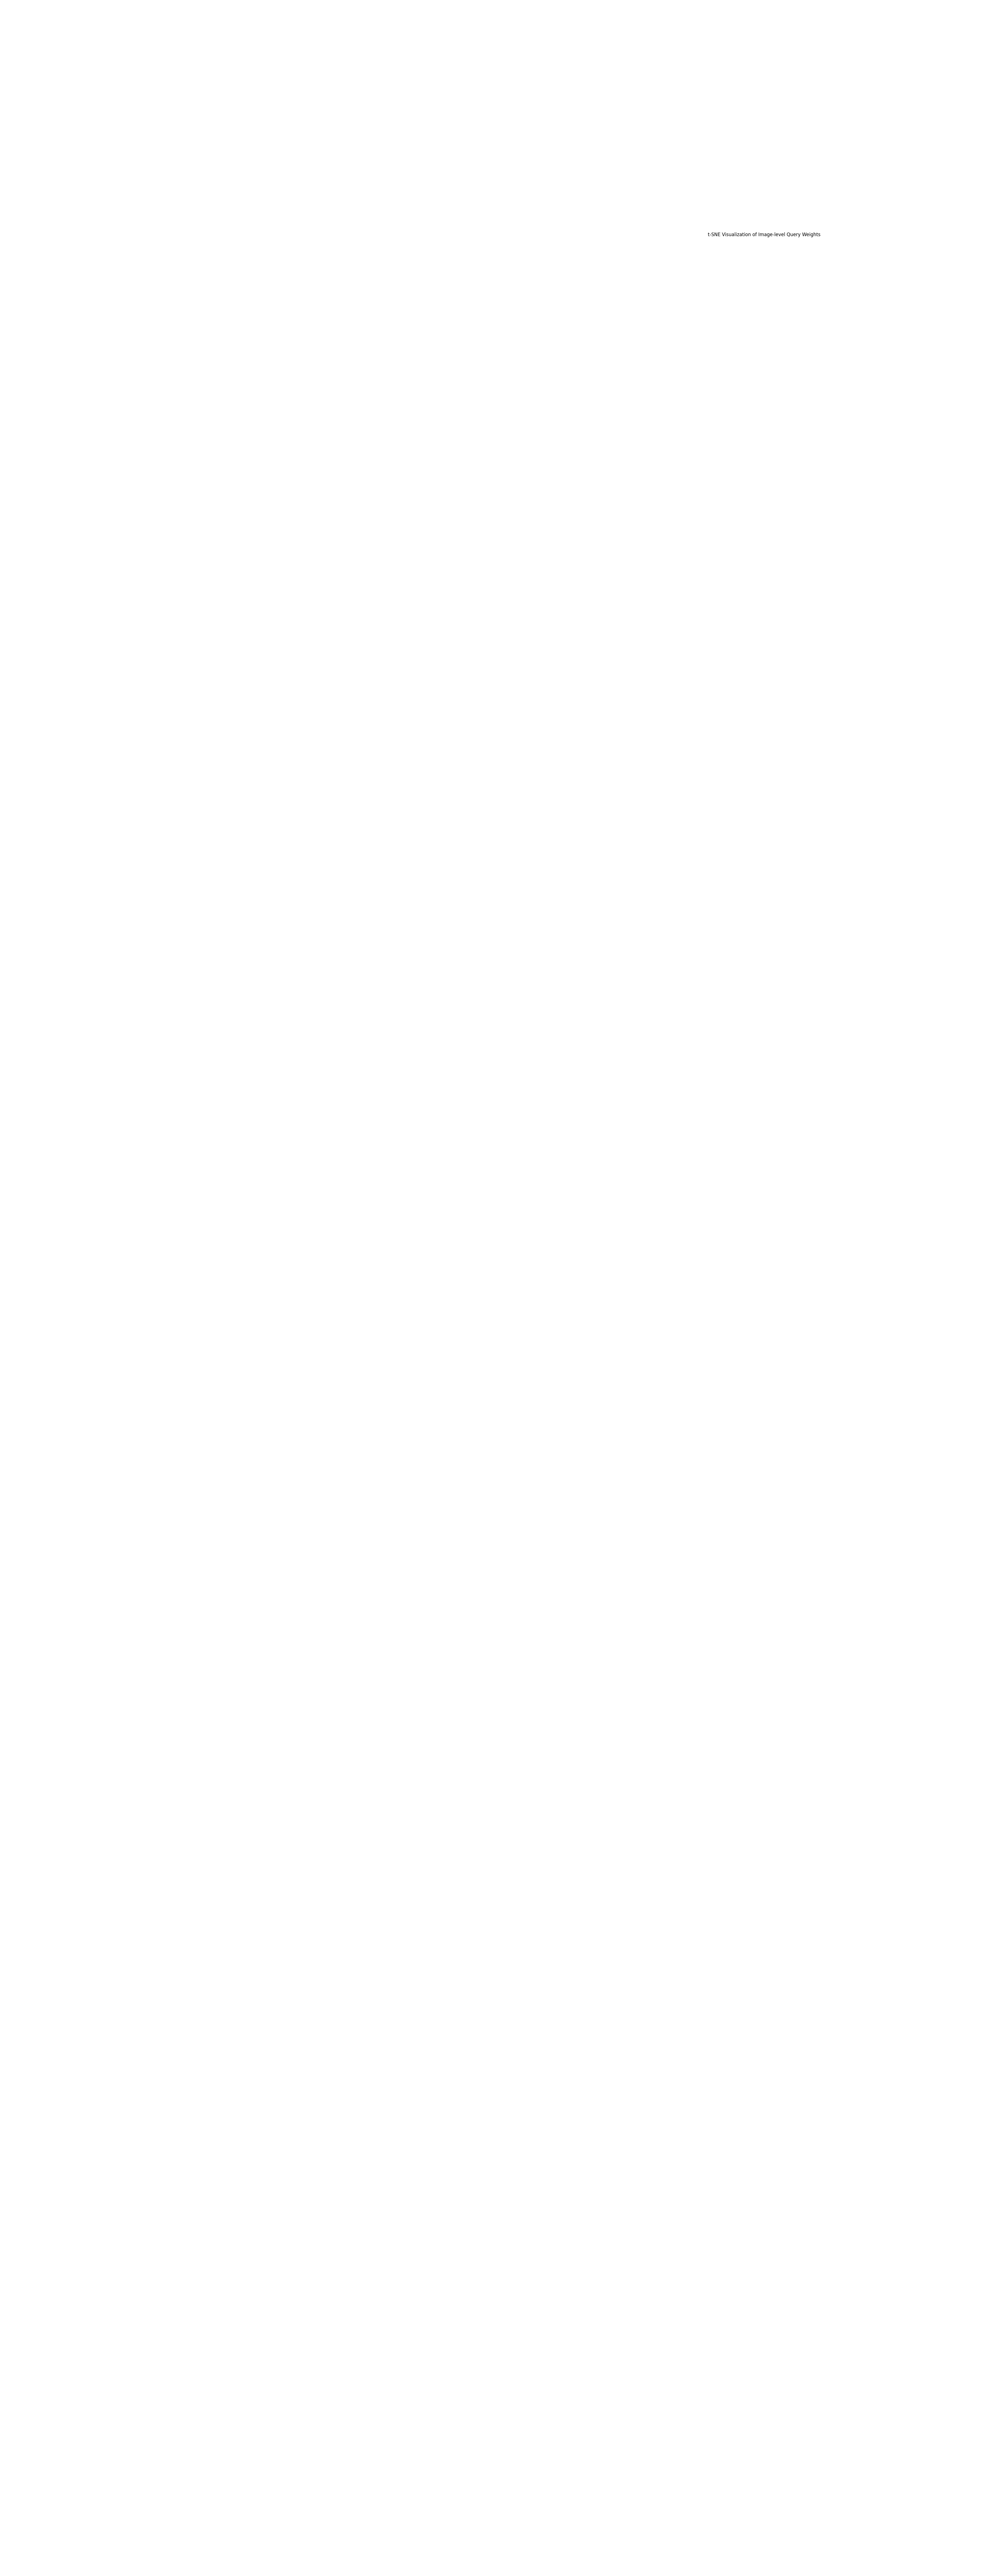

In [115]:
visualize_weights_tsne_scatter(
    weights=combined_weights,
    labels=all_categories,
    image_paths=image_paths,  # 确保传入图片路径
    title="t-SNE Visualization of Image-level Query Weights"
)

In [ ]:
# backup
# 1. 加载图片
selected_categories = [
    'person', 
    # 动物
    'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe',
    # 交通工具
    'car', 'bicycle', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat'
]

images, image_paths, categories = load_single_category_images(
    num_images=200,
    selected_categories=selected_categories
)

# 确保模型在正确的设备上
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 2. 准备存储权重的列表
group_weights_list = []

# 3. 定义hook函数
def hook_fn(module, input, output):
    # print("Hook called!")
    _, weights = output
    group_weights_list.append(weights.detach().cpu())

# 4. 注册hook
hook_handle = model.transformer.group_query_interaction.register_forward_hook(hook_fn)

# 5. 处理图片
all_weights = []
all_categories = []  # 这里定义了all_categories列表

with torch.no_grad():
    for img, cat in tqdm(zip(images, categories)):
        group_weights_list.clear()

        # 将图片移到正确的设备上
        img = img.to(device)

        # 使用正确的输入格式
        predictions = model([img])

        if group_weights_list:
            weights = group_weights_list[0]
            flattened_weights = weights.reshape(1, -1)
            all_weights.append(flattened_weights.numpy())
            all_categories.append(cat)  # 这里收集了类别

# 6. 移除hook
hook_handle.remove()

# 7. 合并所有权重
combined_weights = np.concatenate(all_weights, axis=0)

# 8. 可视化
visualize_weights_tsne(
    weights=combined_weights,
    labels=all_categories,  # 这里使用收集的类别
    title="t-SNE Visualization of Image-level Query Weights by Category Group"
)

In [56]:
def print_model_structure(model, indent=0):
    for name, module in model.named_children():
        print(' ' * indent + f"{name}: {type(module)}")
        print_model_structure(module, indent + 2)

print_model_structure(model)

eval_transform: <class 'torch.nn.modules.container.Sequential'>
  0: <class 'models.detectors.base_detector.EvalResize'>
  1: <class 'transforms.v2._meta.ConvertDtype'>
  2: <class 'transforms.v2._misc.Normalize'>
backbone: <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>
  conv1: <class 'torch.nn.modules.conv.Conv2d'>
  bn1: <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
  relu: <class 'torch.nn.modules.activation.ReLU'>
  maxpool: <class 'torch.nn.modules.pooling.MaxPool2d'>
  layer1: <class 'torch.nn.modules.module.Module'>
    0: <class 'torch.nn.modules.module.Module'>
      conv1: <class 'torch.nn.modules.conv.Conv2d'>
      bn1: <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
      relu: <class 'torch.nn.modules.activation.ReLU'>
      conv2: <class 'torch.nn.modules.conv.Conv2d'>
      bn2: <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
      conv3: <class 'torch.nn.modules.conv.Conv2d'>
      bn3: <class 'torchvision.ops.misc.FrozenBatchNorm2d'

In [48]:
import os
os.environ["NUMEXPR_MAX_THREADS"] = "64"

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_weights_tsne(weights, labels, title="t-SNE Visualization of Group Weights"):
    """
    Args:
        weights: 权重矩阵 [n_samples, n_features]
        labels: 对应的类别标签 [n_samples]
        title: 图表标题
    """
    # 应用t-SNE降维
    tsne = TSNE(n_components=2, random_state=42)
    weights_2d = tsne.fit_transform(weights)
    
    # 创建散点图
    plt.figure(figsize=(12, 8))
    
    # 为不同类别使用不同颜色
    unique_labels = np.unique(labels)
    colors = sns.color_palette("husl", n_colors=len(unique_labels))
    
    for label, color in zip(unique_labels, colors):
        mask = labels == label
        plt.scatter(
            weights_2d[mask, 0],
            weights_2d[mask, 1],
            c=[color],
            label=label,
            alpha=0.6
        )
    
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# t-SNE可视化
visualize_weights_tsne(
    weights=combined_weights.reshape(-1, combined_weights.shape[-1]),
    labels=np.array(numeric_labels),
    title="t-SNE Visualization of Group Weights by Category"
)

In [34]:
image = cv2.imread("/root/autodl-tmp/data/COCO2017/images/val2017/000000005477.jpg")
torch_image = torch.tensor(image.transpose(2, 0, 1))

In [35]:
with torch.no_grad():
    predictions = model([torch_image])[0]
# The following code also works:
# predictions = model(torch_image.unsqueeze(0))[0]

{'scores': tensor([0.9609, 0.6948, 0.3442, 0.3221, 0.2458, 0.2002, 0.1995, 0.1884, 0.1668,
        0.1555, 0.1530, 0.1456, 0.1453, 0.1405, 0.1377, 0.1345, 0.1336, 0.1277,
        0.1270, 0.1242]), 'boxes': tensor([[  8.7401, 104.2985, 634.2976, 289.4631],
        [ 40.7122, 249.3676, 140.6760, 274.1611],
        [ 40.9013, 248.8330, 166.7627, 274.8190],
        [130.2959, 248.6787, 156.3508, 269.1820],
        [129.8290, 248.7177, 171.3015, 270.4235],
        [593.0846, 227.6870, 640.2097, 267.9691],
        [589.0482, 257.2730, 639.9124, 271.5967],
        [592.4857, 256.4509, 639.5776, 267.1884],
        [129.7227, 248.9968, 212.2005, 276.6123],
        [130.0906, 248.6298, 192.4680, 271.4708],
        [589.3969, 260.2928, 639.7876, 271.0092],
        [123.1058, 248.7659, 185.2614, 275.4605],
        [591.7637, 246.4791, 639.5112, 267.9303],
        [133.1676, 256.5011, 153.9489, 268.5654],
        [ 43.6268, 231.7209, 154.4897, 272.7721],
        [130.8712, 248.8339, 143.9440, 265.4

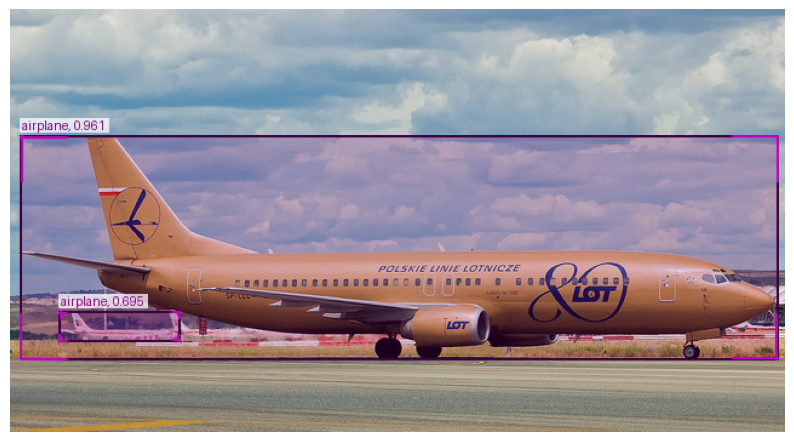

Total predictions for label 1: 24
Top predictions shown: 20


In [36]:
# 1. 获取 label=1 的掩码
mask = predictions['labels'] == 5

# 2. 过滤出 label=1 的结果
filtered_scores = predictions['scores'][mask]
filtered_boxes = predictions['boxes'][mask]
filtered_labels = predictions['labels'][mask]

# 3. 根据分数获取 top 20
if len(filtered_scores) > 20:
    # 获取前20个最高分数的索引
    top_k = 20
    top_scores, top_indices = torch.topk(filtered_scores, min(top_k, len(filtered_scores)))
    
    # 使用这些索引获取对应的框和标签
    top_boxes = filtered_boxes[top_indices]
    top_labels = filtered_labels[top_indices]
else:
    # 如果结果少于20个，全部保留
    top_scores = filtered_scores
    top_boxes = filtered_boxes
    top_labels = filtered_labels

# 4. 创建新的predictions字典
filtered_predictions = {
    'scores': top_scores,
    'boxes': top_boxes,
    'labels': top_labels
}
print(filtered_predictions)


# 5. 可视化结果
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=filtered_predictions["boxes"],
    labels=filtered_predictions["labels"],
    scores=filtered_predictions["scores"],
    classes=model.CLASSES,
    show_conf=0.5,
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

# 显示结果
plt.figure(figsize=(10, 10))
plt.imshow(image_for_show)
plt.axis('off')
plt.show()

# 打印结果数量
print(f"Total predictions for label 1: {len(filtered_scores)}")
print(f"Top predictions shown: {len(top_scores)}")

In [10]:
image = cv2.imread("data/coco/val2017/000000000139.jpg")
torch_image = torch.tensor(image.transpose(2, 0, 1))

## 3. Inference on the image

In [11]:
with torch.no_grad():
    predictions = model([torch_image])[0]
# The following code also works:
# predictions = model(torch_image.unsqueeze(0))[0]

## 4. Visualize results

In [12]:
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=predictions["boxes"],
    labels=predictions["labels"],
    scores=predictions["scores"],
    classes=model.CLASSES,  # class information
    show_conf=0.5,
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

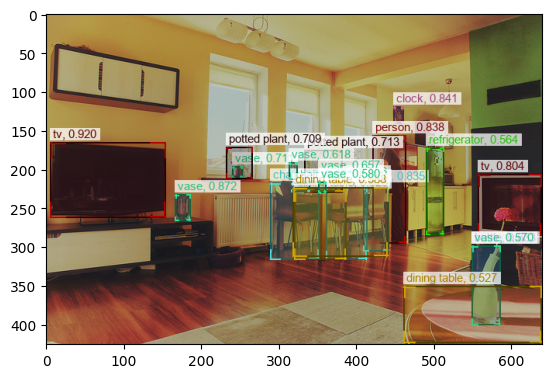

In [13]:
plt.imshow(image_for_show)

In [284]:
import os
import cv2
import json
import random
import torch
import numpy as np
from tqdm import tqdm
from collections import defaultdict, Counter  # 添加 Counter
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# contain only category
def get_category_image_paths_v1(
    category_name,
    image_dir="/root/autodl-tmp/data/COCO2017/images/val2017",
    anno_file="/root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json",
    num_images=100,
    seed=42
):
    """
    获取指定类别的图片路径
    
    Args:
        category_name: 目标类别名称（如'cat'）
        image_dir: 图片目录路径
        anno_file: COCO标注文件路径
        num_images: 需要返回的图片数量
        seed: 随机种子
    
    Returns:
        list: 图片路径列表
    """
    # 设置随机种子
    random.seed(seed)
    
    # 读取标注文件
    print(f"Loading annotations from {anno_file}")
    with open(anno_file, 'r') as f:
        coco_data = json.load(f)
    
    # 创建必要的映射
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # 找到目标类别的ID
    category_id = None
    for cat in coco_data['categories']:
        if cat['name'].lower() == category_name.lower():
            category_id = cat['id']
            break
    
    if category_id is None:
        raise ValueError(f"Category '{category_name}' not found in dataset")
    
    # 收集只包含目标类别的图片
    print(f"Finding images containing only {category_name}...")
    image_categories = defaultdict(set)
    for ann in coco_data['annotations']:
        image_categories[ann['image_id']].add(ann['category_id'])
    
    # 筛选只包含目标类别的图片
    target_images = []
    for img_id, categories in image_categories.items():
        if len(categories) == 1 and category_id in categories:
            img_file = image_id_to_file[img_id]
            img_path = os.path.join(image_dir, img_file)
            target_images.append(img_path)
    
    # 随机选择指定数量的图片
    selected_images = random.sample(
        target_images, 
        min(num_images, len(target_images))
    )
    
    print(f"Found {len(target_images)} images containing only {category_name}")
    print(f"Randomly selected {len(selected_images)} images")
    
    return selected_images

# # 使用示例：
# # cat_image_paths = get_category_image_paths(
# #     category_name='cat',
# #     num_images=100
# # )

In [258]:
# contain at least one category, others can exist
def get_category_image_paths_v2(
    category_name,
    image_dir="/root/autodl-tmp/data/COCO2017/images/val2017",
    anno_file="/root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json",
    num_images=100,
    seed=42
):
    """
    获取包含指定类别的图片路径
    
    Args:
        category_name: 目标类别名称（如'cat'）
        image_dir: 图片目录路径
        anno_file: COCO标注文件路径
        num_images: 需要返回的图片数量
        seed: 随机种子
    
    Returns:
        list: 图片路径列表
    """
    # 设置随机种子
    random.seed(seed)
    
    # 读取标注文件
    print(f"Loading annotations from {anno_file}")
    with open(anno_file, 'r') as f:
        coco_data = json.load(f)
    
    # 创建必要的映射
    image_id_to_file = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # 找到目标类别的ID
    category_id = None
    for cat in coco_data['categories']:
        if cat['name'].lower() == category_name.lower():
            category_id = cat['id']
            break
    
    if category_id is None:
        raise ValueError(f"Category '{category_name}' not found in dataset")
    
    # 收集包含目标类别的图片
    print(f"Finding images containing {category_name}...")
    target_images = set()  # 使用集合避免重复
    for ann in coco_data['annotations']:
        if ann['category_id'] == category_id:
            img_id = ann['image_id']
            img_file = image_id_to_file[img_id]
            img_path = os.path.join(image_dir, img_file)
            target_images.add(img_path)
    
    # 转换为列表并随机选择指定数量的图片
    target_images = list(target_images)
    selected_images = random.sample(
        target_images, 
        min(num_images, len(target_images))
    )
    
    print(f"Found {len(target_images)} images containing {category_name}")
    print(f"Randomly selected {len(selected_images)} images")
    
    return selected_images

# 使用示例：
# cat_image_paths = get_category_image_paths(
#     category_name='cat',
#     num_images=100
# )

In [301]:
# Step 0: configuration params
category = 'airplane'
cat_class_id = 5

num_images = 200
threshold = 0.7
top_k = 30 # top k weight of subspace queries (pattern)

all_cat_group_weights = [] # seleted weights of patterns of topk
all_cat_query_indexes = [] # selected query indexes


In [302]:
# Step 1 获取100张只包含猫的图片路径
cat_image_paths = get_category_image_paths_v2(
    category_name=category,
    num_images=num_images
)
cat_image_paths = cat_image_paths[:]
print(len(cat_image_paths))
# print(cat_image_paths)

Loading annotations from /root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json
Finding images containing airplane...
Found 97 images containing airplane
Randomly selected 97 images
97


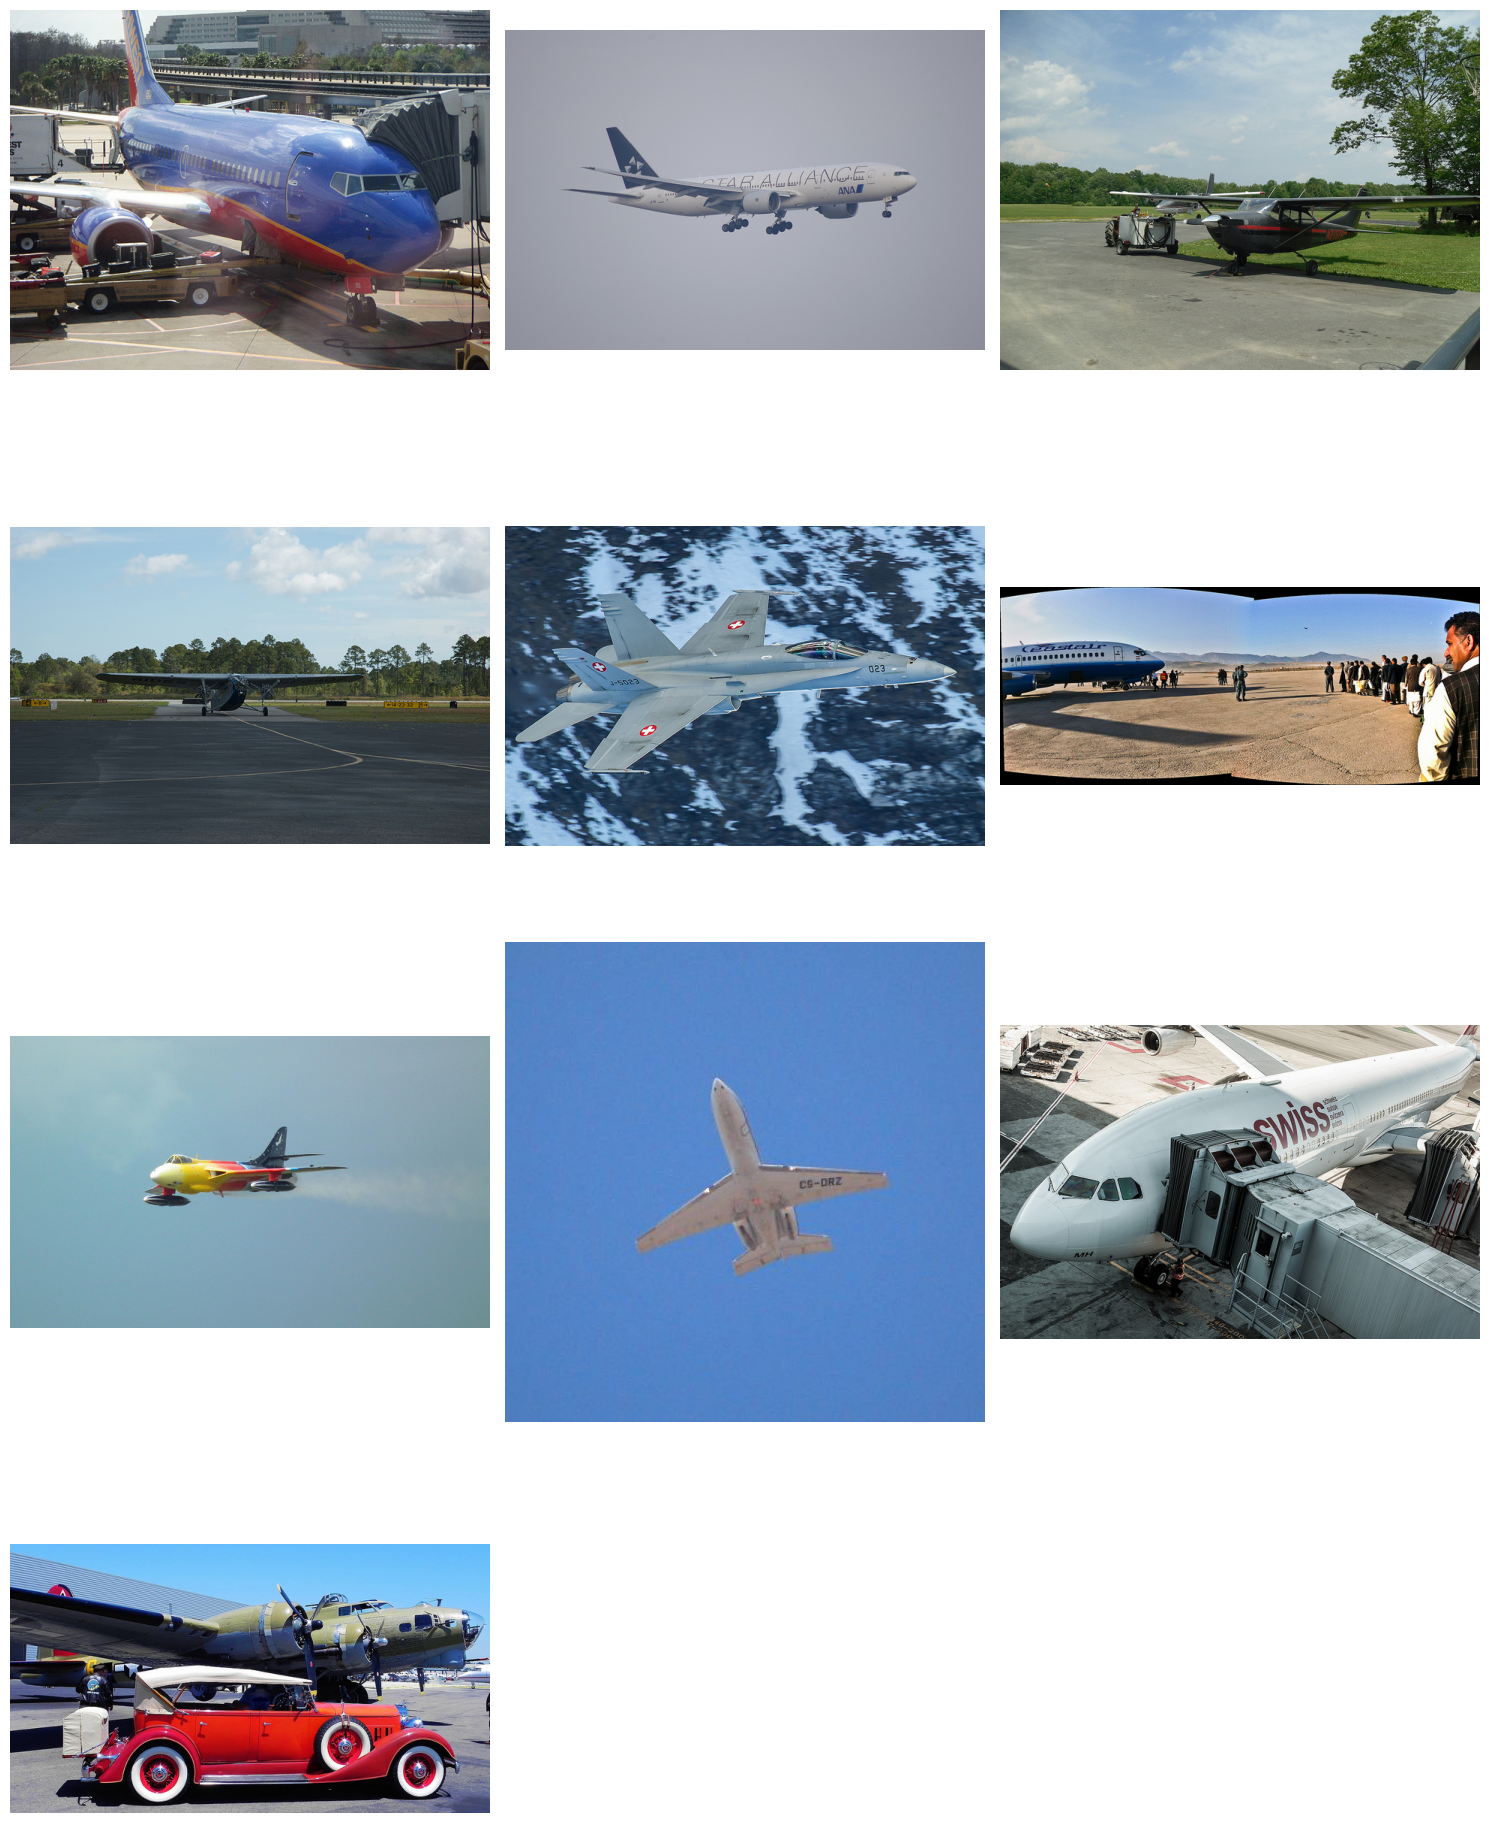

In [303]:
def display_images(images, num_cols=3):
    """显示多张图片
    
    Args:
        images: list of numpy arrays, BGR格式
        num_cols: 每行显示的图片数量
    """
    num_images = len(images)
    num_rows = (num_images + num_cols - 1) // num_cols
    
    plt.figure(figsize=(5*num_cols, 5*num_rows))
    for i, image in enumerate(images):
        plt.subplot(num_rows, num_cols, i+1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 使用示例：
images = [cv2.imread(path) for path in cat_image_paths[:15]]  # 显示6张图片
display_images(images)

In [293]:
# Step 2
import importlib
import models.detectors.dino
importlib.reload(models.detectors.dino)

import configs.dino_pp.dino_pp_resnet50_800_1333
importlib.reload(configs.dino_pp.dino_pp_resnet50_800_1333)


from configs.dino_pp.dino_pp_resnet50_800_1333 import model
weight = load_checkpoint("/root/autodl-tmp/dino/dino-v3.1-cur-24ep_dino_pp_resnet50_800_1333/train/decoder-query-optm-v3.3.1-stable-group-div-sparse-loss_2025-01-21-15_36_02/best_ap.pth")
load_state_dict(model, weight)
model = model.eval()

In [304]:
group_weights_list = [] # for hook

def hook_fn(module, input, output):
    _, weights = output
    group_weights_list.append(weights.detach().cpu())

# 注册hook
hook = model.transformer.group_query_interaction.register_forward_hook(hook_fn)


for image_path in cat_image_paths:
    image = cv2.imread(image_path)
    torch_image = torch.tensor(image.transpose(2, 0, 1))

    with torch.no_grad():
        group_weights_list.clear()
        outputs = model([torch_image])[0]
        group_weights = group_weights_list[0][0]  # 获取最新的group_weights for batch
        # print(outputs['pred_logits'].shape)
        # print(outputs['pred_boxes'].shape)

        pred_logits = outputs['pred_logits'][0]  # [900, num_classes+1]
        probs = pred_logits.sigmoid()

        cat_probs = probs[:, cat_class_id]  # [900]
        # 找出所有预测为猫且置信度高的query
        cat_keep = cat_probs > threshold
        
        selected_query_indices = torch.where(cat_keep)[0]
        print("Selected query indices:", selected_query_indices.tolist())
        all_cat_query_indexes.extend(selected_query_indices)

        cat_probs = cat_probs[cat_keep]
        cat_query_weights = group_weights[cat_keep, :]  # [num_cat_queries, 300]
        all_cat_group_weights.append(cat_query_weights)
        # print(cat_probs)
        # print(cat_query_weights)

        # top_weights, top_indices = cat_query_weights.topk(top_k, dim=1)  # values和indices
        # print(f"Found {cat_query_weights.shape[0]} queries predicting cat")
        # for query_idx in range(len(cat_query_weights)):
        #     print(f"\nCat Query {query_idx} (confidence: {cat_probs[query_idx]:.3f}):")
        #     print("Top 30 patterns:")
        #     for i, (idx, weight) in enumerate(zip(top_indices[query_idx], top_weights[query_idx])):
        #         print(f"  Pattern {idx.item():3d}: {weight.item():.3f}")

                
# 3. 合并所有的weights
all_cat_group_weights = torch.cat(all_cat_group_weights, dim=0)  # [total_cat_queries, 300]
print(f"Total number of cat queries across all images: {all_cat_group_weights.shape[0]}")
print(selected_query_indices)

# 移除hook
hook.remove()

Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0, 2]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [2]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0, 1, 2, 3, 4, 9, 14]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0, 4]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [3]
Selected query indices: []
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0, 2]
Selected query indices: [0]
Selected query indices: []
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0]
Selected query indices: [0, 1]
Selected query indices: [0]
Selected query indi

torch.Size([112, 300])


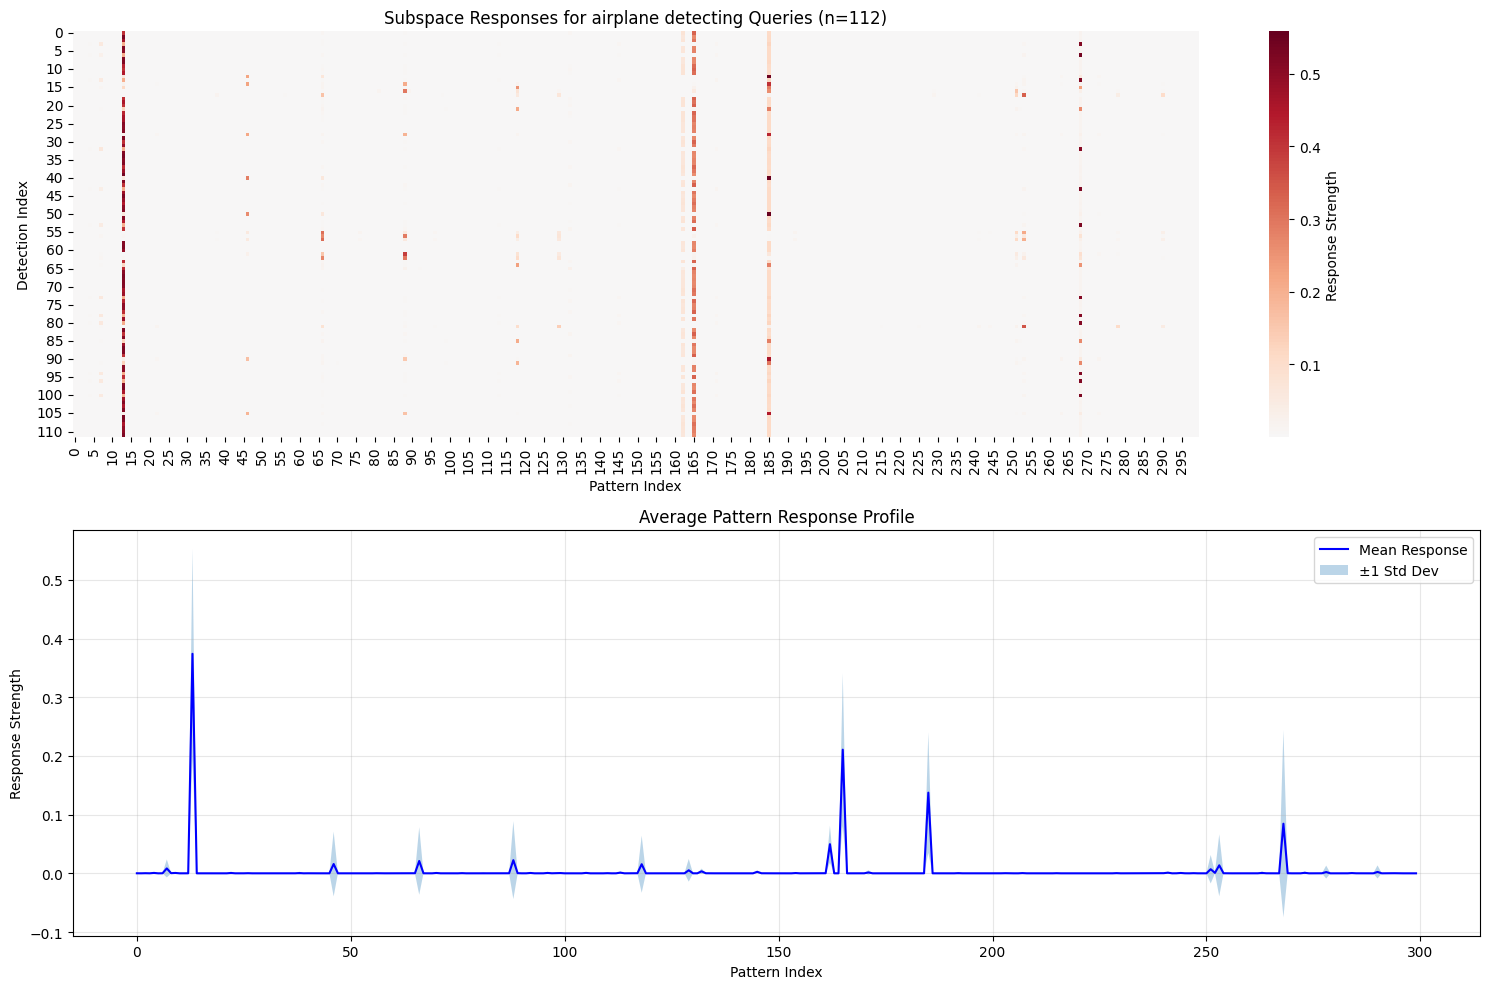


Top 10 most responsive patterns:
Pattern  13: mean=0.374, std=0.179
Pattern 165: mean=0.211, std=0.130
Pattern 185: mean=0.137, std=0.103
Pattern 268: mean=0.085, std=0.159
Pattern 162: mean=0.050, std=0.032
Pattern  88: mean=0.022, std=0.066
Pattern  66: mean=0.021, std=0.058
Pattern  46: mean=0.016, std=0.055
Pattern 118: mean=0.016, std=0.049
Pattern 253: mean=0.014, std=0.053


In [305]:
def analyze_cat_detection_patterns(cat_query_weights, category):
    """分析预测猫的query的pattern响应模式
    
    Args:
        cat_query_weights: tensor [num_cat_queries, num_patterns]
    """
    plt.figure(figsize=(15, 10))
    
    # 1. 绘制热力图
    plt.subplot(211)
    sns.heatmap(cat_query_weights.cpu().numpy(), 
                cmap='RdBu_r',
                center=0,
                cbar_kws={'label': 'Response Strength'})
    plt.title(f'Subspace Responses for {category} detecting Queries (n={len(cat_query_weights)})')
    plt.xlabel('Pattern Index')
    plt.ylabel('Detection Index')
    
    # 2. 绘制平均响应
    plt.subplot(212)
    mean_response = cat_query_weights.mean(dim=0).cpu().numpy()
    std_response = cat_query_weights.std(dim=0).cpu().numpy()
    
    x = np.arange(len(mean_response))
    plt.plot(x, mean_response, 'b-', label='Mean Response')
    plt.fill_between(x, 
                     mean_response - std_response,
                     mean_response + std_response,
                     alpha=0.3,
                     label='±1 Std Dev')
    plt.grid(True, alpha=0.3)
    plt.title('Average Pattern Response Profile')
    plt.xlabel('Pattern Index')
    plt.ylabel('Response Strength')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 3. 打印一些统计信息
    print("\nTop 10 most responsive patterns:")
    top_patterns = torch.topk(torch.mean(cat_query_weights, dim=0), k=10)
    for idx, (pattern_idx, response) in enumerate(zip(top_patterns.indices, top_patterns.values)):
        print(f"Pattern {pattern_idx.item():3d}: mean={response.item():.3f}, "
              f"std={cat_query_weights[:, pattern_idx].std().item():.3f}")
    
    return mean_response, std_response

# 使用示例：
print(all_cat_group_weights.shape)
mean_response, std_response = analyze_cat_detection_patterns(all_cat_group_weights, category)

In [309]:
def analyze_cat_detection_patterns(cat_query_weights, category_name, save_dir='results/pattern_analysis'):
    """分析特定类别的query的pattern响应模式
    
    Args:
        cat_query_weights: tensor [num_cat_queries, num_patterns]
        category_name: str, 类别名称（用于保存文件）
        save_dir: str, 保存结果的目录
    """
    # 创建保存目录
    os.makedirs(save_dir, exist_ok=True)
    
    # 创建更紧凑的图
    plt.figure(figsize=(12, 2.5))
    
    # 1. 绘制热力图
    plt.subplot(121)
    num_patterns = cat_query_weights.shape[1] + 1
    num_queries = cat_query_weights.shape[0] + 1
    x_ticks = np.arange(0, num_patterns, 50)  # 每50个pattern显示一个刻度
    y_ticks = np.arange(0, num_queries, max(1, num_queries//5))  # 纵向显示5个刻度
    
    sns.heatmap(cat_query_weights.cpu().numpy(), 
                cmap='RdBu_r',
                center=0,
                xticklabels=x_ticks,  # 设置x轴刻度
                yticklabels=y_ticks)  # 设置y轴刻度
    plt.xticks(x_ticks, x_ticks)
    plt.yticks(y_ticks, y_ticks)
    
    plt.title(f'pattern activation for `$\it{{{category_name}}}$` detection queries')
    plt.xlabel('pattern index')
    plt.ylabel('detection queries')
    
    # 2. 绘制平均响应
    plt.subplot(122)
    mean_response = cat_query_weights.mean(dim=0).cpu().numpy()
    std_response = cat_query_weights.std(dim=0).cpu().numpy()
    
    x = np.arange(len(mean_response))
    plt.plot(x, mean_response, 'b-', label='mean response')
    plt.fill_between(x, 
                     mean_response - std_response,
                     mean_response + std_response,
                     alpha=0.3,
                     label='±1 std dev')
    plt.grid(True, alpha=0.3)
    plt.title(f'average pattern activation for `$\it{{{category_name}}}$`')
    plt.xlabel('pattern index')
    plt.ylabel('response strength')
    plt.legend()
    
    plt.tight_layout()
    
    # 保存图片
    save_path = os.path.join(save_dir, f'pattern_analysis_{category_name}.pdf')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    # 打印统计信息
    print(f"\nPattern analysis for {category_name}")
    print(f"Number of queries: {len(cat_query_weights)}")
    print("\nTop 10 most responsive patterns:")
    top_patterns = torch.topk(torch.mean(cat_query_weights, dim=0), k=10)
    for idx, (pattern_idx, response) in enumerate(zip(top_patterns.indices, top_patterns.values)):
        print(f"Pattern {pattern_idx.item():3d}: mean={response.item():.3f}, "
              f"std={cat_query_weights[:, pattern_idx].std().item():.3f}")
    
    print(f"\nResults saved to {save_path}")
    return mean_response, std_response

# mean_response, std_response = analyze_cat_detection_patterns(
#     cat_query_weights=all_cat_group_weights,
#     category_name=category,
#     save_dir='results/pattern_analysis'
# )

In [249]:
all_cat_group_weights.shape

torch.Size([6, 300])

In [196]:
successful_queries = []
cat_class_id = 17  # 修正为正确的猫类别ID
group_weights_list = []  # 存储hook获取的group_weights

def hook_fn(module, input, output):
    _, weights = output
    group_weights_list.append(weights.detach().cpu())

# 4. 注册hook
hook = model.transformer.group_query_interaction.register_forward_hook(hook_fn)

image = cv2.imread(cat_image_paths[0])
torch_image = torch.tensor(image.transpose(2, 0, 1))

In [160]:
cat_image_paths[0]

'/root/autodl-tmp/data/COCO2017/images/val2017/000000063552.jpg'

In [171]:
model = model.cpu()

In [187]:
image = cv2.imread(cat_image_paths[0])
torch_image = torch.tensor(image.transpose(2, 0, 1))

with torch.no_grad():
    predictions = model([torch_image])[0]
# The following code also works:
# predictions = model(torch_image.unsqueeze(0))[0]

hook called
hook called


In [173]:
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=predictions["boxes"],
    labels=predictions["labels"],
    scores=predictions["scores"],
    classes=model.CLASSES,  # class information
    show_conf=0.5,
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

In [168]:
print(predictions['labels'])

tensor([17, 62, 62,  3,  4, 18, 62,  3, 81, 65,  2, 17,  2, 65,  1, 62, 62,  1,
         4, 62, 18,  3,  1,  1, 51, 81,  2,  3,  1, 62], device='cuda:0')


In [175]:
print(predictions['scores'])

tensor([0.9043, 0.7379, 0.4617, 0.3862, 0.2643, 0.2500, 0.2430, 0.2343, 0.2287,
        0.2241, 0.2073, 0.2044, 0.2021, 0.1991, 0.1694, 0.1581, 0.1550, 0.1525,
        0.1462, 0.1449, 0.1433, 0.1427, 0.1354, 0.1300, 0.1278, 0.1277, 0.1267,
        0.1254, 0.1253, 0.1222])


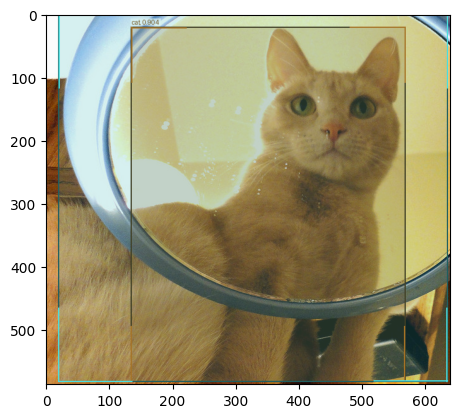

In [174]:
plt.imshow(image_for_show)

Loading annotations from /root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json
Finding images containing person...
Found 2693 images containing person
Randomly selected 200 images
Start processing category person ...
Selected query indices: [1, 4, 5, 7, 9, 11, 13, 14, 16, 19, 32, 43]
Total number of cat queries across all images: 12
tensor([ 1,  4,  5,  7,  9, 11, 13, 14, 16, 19, 32, 43])


IndexError: list index out of range

In [310]:
category_class_ids = [('person',1), ('bicycle', 2), ('car', 3), 
                      ('motorcycle', 4), ('airplane', 5), ('bus', 6), 
                      ('train', 7), ('truck', 8), ('sandwich', 54), ('keyboard', 76)]

num_images = 200
threshold = 0.6
top_k = 30

for category, cat_class_id in category_class_ids:
    # 为每个类别重新初始化列表
    all_cat_group_weights = []  # selected weights of patterns of topk
    all_cat_query_indexes = []  # selected query indexes
    group_weights_list = []     # for hook
    
    def hook_fn(module, input, output):
        _, weights = output
        group_weights_list.append(weights.detach().cpu())

    # 注册hook
    hook = model.transformer.group_query_interaction.register_forward_hook(hook_fn)
    
    print(f'\nStart processing category {category} ...')
    
    cat_image_paths = get_category_image_paths_v2(
        category_name=category,
        num_images=num_images
    )

    for image_path in cat_image_paths:
        image = cv2.imread(image_path)
        torch_image = torch.tensor(image.transpose(2, 0, 1))

        with torch.no_grad():
            group_weights_list.clear()
            outputs = model([torch_image])[0]
            group_weights = group_weights_list[0][0]  # 获取最新的group_weights for batch

            pred_logits = outputs['pred_logits'][0]  # [900, num_classes+1]
            probs = pred_logits.sigmoid()

            cat_probs = probs[:, cat_class_id]  # [900]
            cat_keep = cat_probs > threshold

            selected_query_indices = torch.where(cat_keep)[0]
            all_cat_query_indexes.extend(selected_query_indices.tolist())

            cat_probs = cat_probs[cat_keep]
            cat_query_weights = group_weights[cat_keep, :]  # [num_cat_queries, 300]
            
            if len(cat_query_weights) > 0:  # 只有当有检测到目标时才添加
                all_cat_group_weights.append(cat_query_weights)

    # 移到循环外：合并所有图片的weights
    if len(all_cat_group_weights) > 0:  # 确保有检测结果
        all_cat_group_weights = torch.cat(all_cat_group_weights, dim=0)  # [total_cat_queries, 300]
        print(f"Total number of {category} queries: {all_cat_group_weights.shape[0]}")
        print(f"Query indices distribution: {Counter(all_cat_query_indexes)}")
        
        mean_response, std_response = analyze_cat_detection_patterns(
            cat_query_weights=all_cat_group_weights,
            category_name=category,
            save_dir='results/pattern_analysis'
        )
    else:
        print(f"No detection found for category {category}")

    # 移除hook
    hook.remove()
    print(f'End processing category {category}')


Start processing category person ...
Loading annotations from /root/autodl-tmp/data/COCO2017/annotations/instances_val2017.json
Finding images containing person...
Found 2693 images containing person
Randomly selected 200 images
Total number of person queries: 590
Query indices distribution: Counter({0: 137, 2: 73, 4: 62, 9: 46, 1: 30, 13: 28, 7: 27, 5: 25, 3: 19, 14: 14, 8: 14, 10: 13, 20: 12, 11: 8, 19: 8, 6: 7, 18: 6, 15: 6, 17: 6, 32: 4, 12: 4, 24: 4, 22: 4, 16: 3, 26: 3, 25: 2, 33: 2, 40: 2, 27: 2, 28: 2, 43: 1, 47: 1, 38: 1, 41: 1, 48: 1, 31: 1, 37: 1, 51: 1, 58: 1, 842: 1, 30: 1, 42: 1, 44: 1, 104: 1, 74: 1, 59: 1, 29: 1})

Pattern analysis for person
Number of queries: 590

Top 10 most responsive patterns:
Pattern 185: mean=0.152, std=0.151
Pattern  13: mean=0.147, std=0.174
Pattern 268: mean=0.124, std=0.173
Pattern 165: mean=0.081, std=0.131
Pattern  88: mean=0.071, std=0.119
Pattern  66: mean=0.057, std=0.092
Pattern 253: mean=0.042, std=0.088
Pattern 251: mean=0.039, std=0

In [ ]:
# 对同一张图片，看不同类别的预测
with torch.no_grad():
    outputs = model([torch_image])
    pred_logits = outputs['pred_logits'][0]  # [900, num_classes+1]
    probs = pred_logits.sigmoid()
    group_weights = group_weights_list[-1][0]  # [900, 300]

    # 对几个不同的类别
    for category, class_id in category_class_ids:
        class_probs = probs[:, class_id]
        keep = class_probs > threshold
        selected_queries = torch.where(keep)[0]
        
        print(f"\nCategory: {category}")
        print(f"Selected queries: {selected_queries.tolist()}")
        if len(selected_queries) > 0:
            # 看看这些query激活了哪些pattern
            query_weights = group_weights[selected_queries]
            top_patterns = query_weights.mean(dim=0).topk(5)
            print("Top 5 patterns:", top_patterns.indices.tolist())

In [ ]:
def analyze_multi_class_patterns(image_path, category_class_ids, threshold=0.6):
    """分析同一张图片中不同类别的pattern分布
    
    Args:
        image_path: 图片路径
        category_class_ids: List of (category_name, class_id) tuples
        threshold: 置信度阈值
    """
    image = cv2.imread(image_path)
    torch_image = torch.tensor(image.transpose(2, 0, 1))
    
    group_weights_list = []
    def hook_fn(module, input, output):
        _, weights = output
        group_weights_list.append(weights.detach().cpu())
    
    hook = model.transformer.group_query_interaction.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        group_weights_list.clear()
        outputs = model([torch_image])[0]
        group_weights = group_weights_list[0][0]  # [900, 300]
        pred_logits = outputs['pred_logits'][0]  # [900, num_classes+1]
        probs = pred_logits.sigmoid()
        
        # 显示原图
        plt.figure(figsize=(15, 5))
        plt.subplot(131)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')
        
        # 收集每个类别的信息
        class_patterns = {}
        for category, class_id in category_class_ids:
            class_probs = probs[:, class_id]
            keep = class_probs > threshold
            selected_queries = torch.where(keep)[0]
            
            if len(selected_queries) > 0:
                query_weights = group_weights[selected_queries]  # [num_queries, 300]
                class_patterns[category] = {
                    'queries': selected_queries,
                    'confidences': class_probs[selected_queries],
                    'patterns': query_weights
                }
                print(f"\nCategory: {category}")
                print(f"Number of queries: {len(selected_queries)}")
                print(f"Query indices: {selected_queries.tolist()}")
                print(f"Confidences: {class_probs[selected_queries].tolist()}")
        
        # 绘制pattern分布对比
        if class_patterns:
            plt.subplot(132)
            for category, data in class_patterns.items():
                mean_pattern = data['patterns'].mean(dim=0)
                plt.plot(mean_pattern.numpy(), label=category, alpha=0.7)
            plt.title('Pattern Response Distribution')
            plt.xlabel('Pattern Index')
            plt.ylabel('Mean Response')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # 绘制query-pattern热力图
            plt.subplot(133)
            all_patterns = []
            categories = []
            for category, data in class_patterns.items():
                all_patterns.append(data['patterns'])
                categories.extend([category] * len(data['queries']))
            
            if all_patterns:
                all_patterns = torch.cat(all_patterns, dim=0)
                sns.heatmap(all_patterns.numpy(), 
                           cmap='RdBu_r',
                           center=0,
                           cbar_kws={'label': 'Response Strength'})
                plt.title('Query-Pattern Response')
                plt.xlabel('Pattern Index')
                plt.yticks(range(len(categories)), categories)
        
        plt.tight_layout()
        plt.show()
    
    hook.remove()
    return class_patterns

# 使用示例：
image_path = "path/to/your/image.jpg"  # 包含多个目标的图片
results = analyze_multi_class_patterns(image_path, category_class_ids, threshold=0.6)